In [693]:
import subprocess
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import scipy.optimize as so
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
import subprocess
from scipy.optimize import curve_fit
sns.set()
sns.set_context('paper', font_scale=1.2)
from scipy.optimize import nnls#######################################################################################################################################################################################################
#######################################################################################################################################################################################################
# Path: Newsimulation.ipynb
#######################################################################################################################################################################################################
#######################################################################################################################################################################################################

# Parse EnergyPlus datetime string
energyplus_install_dir=r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\EnergyPlusV9-6-0"
output_relative_directory =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change"
idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\SmallOffice.idf"
epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\USA_WA_Bellingham.Intl.AP.727976_US.Normals.1981-2010.epw"
#epw_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\USA_CO_Golden-NREL.724666_TMY3.epw"

#mychange - idf_relative_filepath = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\AirflowNetwork_MultiZone_SmallOffice_VAV111.idf"
#USA_CA_San.Francisco.Intl.AP.724940_TMY3
#USA_CO_Golden-NREL.724666_TMY3
def run_command(cmd_string, capture_output=False):
    # sourcery skip: raise-specific-error
    result = subprocess.run(cmd_string, capture_output=capture_output)
    if result.returncode != 0:
        raise Exception(f'Command failed with return code: {result.returncode}')
    print('---RETURNCODE---\n', result.returncode, '(SUCCESS)')
    return result



# building command string
cl_st=(f'"{energyplus_install_dir}\\energyplus" '
       + '--readvars '
       + f'--output-directory "{output_relative_directory}" '
       + f'--weather "{epw_relative_filepath}" '
       + f'"{idf_relative_filepath}"'
      )


# running the simulation
run_command(cl_st)

---RETURNCODE---
 0 (SUCCESS)


CompletedProcess(args='"D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\EnergyPlusV9-6-0\\energyplus" --readvars --output-directory "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\DOF_change" --weather "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\USA_WA_Bellingham.Intl.AP.727976_US.Normals.1981-2010.epw" "D:\\PhD_Academics\\Buildings\\Tharaka\\Tharaka\\meeting\\james\\week4_solar_and_new_cost_function\\SmallOffice.idf"', returncode=0)

In [694]:
# function to parse EnergyPlus datetime string
def parse_energyplus_datetime_string(st, year=2021):
    st = st.strip()
    month, day = map(int, [st[:2], st[3:5]])
    hour = int(st[7:9]) if st[7:9] != '24' else 0
    minute = int(st[10:12])
    dt = pd.Timestamp(year, month, day, hour, minute)
    return dt if st[7:9] != '24' else dt + pd.Timedelta('1 day')

In [695]:
df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv",
               parse_dates=[0],
               index_col=[0],
               date_parser=parse_energyplus_datetime_string
              )

df_sim = pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv")

C:\Users\USER\AppData\Local\Temp\ipykernel_14496\3946068532.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df=pd.read_csv(r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\eplusout.csv",


In [696]:
rename_dict = {
    "NORTH ZONE:Zone Air Temperature [C](TimeStep)": "North_Zone_Air_Temperature", 
    "WEST ZONE:Zone Air Temperature [C](TimeStep)": "West_Zone_Air_Temperature", 
    "EAST ZONE:Zone Air Temperature [C](TimeStep)": "East_Zone_Air_Temperature", 
    "Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)": "Ambient_Temperature", 
    "MAIN HEATING COIL 1:Heating Coil Heating Rate [W](TimeStep)": "Heating_Power", 
    "ZONE3TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z1",
    "ZONE1TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z2",
    "ZONE2TERMREHEAT:Zone Air Terminal Sensible Heating Rate [W](TimeStep)": "Heating_Power_Z3",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "North_Zone_Solar_Rate",
    "NORTH ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "North_Zone_Solar_Energy",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "West_Zone_Solar_Rate",
    "WEST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "West_Zone_Solar_Energy",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Rate [W](TimeStep)": "East_Zone_Solar_Rate",
    "EAST ZONE:Zone Windows Total Transmitted Solar Radiation Energy [J](TimeStep)": "East_Zone_Solar_Energy",
    "Date/Time": "Time"
}

In [697]:
df.rename(columns=rename_dict, inplace=True)
time_steps = np.arange(len(df))

In [698]:
df['time_steps'] = time_steps

In [699]:
minutes_to_plot = 2592000  # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# create and modify Heating Input column
df['Heating Input'] = df['Heating_Power'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z1'] = df['Heating_Power_Z1'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z2'] = df['Heating_Power_Z2'].apply(lambda x: 1 if x > 0 else 0).astype(int)
df['Heating_Input_Z3'] = df['Heating_Power_Z3'].apply(lambda x: 1 if x > 0 else 0).astype(int)

# Format the current date and time
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')


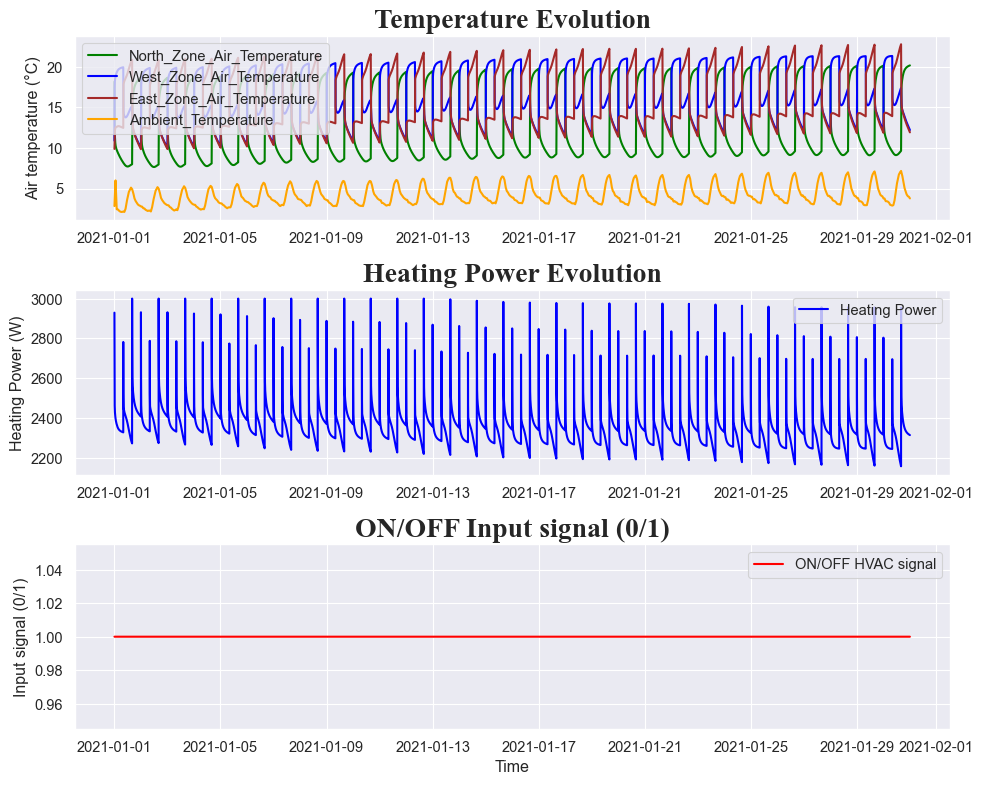

In [700]:
# Specify the path and filename and save the DataFrame to a new CSV file
file_path =  r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change"
filename = f"{file_path}imulation_results_{timestamp}.csv"
filename2 = r'D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Indoor_Temperatures2.csv'
# Specify the file path

df.to_csv(filename, index=False)
df.to_csv(filename2, index=False)


fig, axs = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)
minutes_to_plot = 2592000   # Define the number of minutes to plot

# Ensure that we have enough data to plot 200 minutes
if len(df) > minutes_to_plot:
    plot_data = df.iloc[:minutes_to_plot]
else:
    plot_data = df  # Not enough data, use what we have

# Plot T_int1, T_int2, T_int3, T_ext
for temp, color in zip(['North_Zone_Air_Temperature', 'West_Zone_Air_Temperature', 'East_Zone_Air_Temperature', 'Ambient_Temperature'], ['green', 'blue', 'brown', 'orange']):
    axs[0].plot(plot_data.index, plot_data[temp], color=color, linewidth=1.5, label=temp)
axs[0].set(ylabel='Temperature (°C)')
axs[0].legend(loc='best')
axs[0].set_ylabel('Air temperature (°C)')
axs[0].set_title('Temperature Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea1
axs[1].plot(plot_data.index, plot_data['Heating_Power'], color='blue', linewidth=1.5, label='Heating Power')
axs[1].set(ylabel='Heating Power (W)')
axs[1].legend(loc='best')
axs[1].set_ylabel('Heating Power (W)')
axs[1].set_title('Heating Power Evolution', fontname="Times New Roman", size=20, fontweight="bold")

# Plot P_hea2
axs[2].plot(plot_data.index, plot_data['Heating Input'], color='red', linewidth=1.5, label='ON/OFF HVAC signal')
axs[2].set(xlabel='Time', ylabel='P_hea2')
axs[2].legend(loc='best')
axs[2].set_ylabel('Input signal (0/1)')
axs[2].set_title('ON/OFF Input signal (0/1)', fontname="Times New Roman", size=20, fontweight="bold")



plt.show()

plt.show()




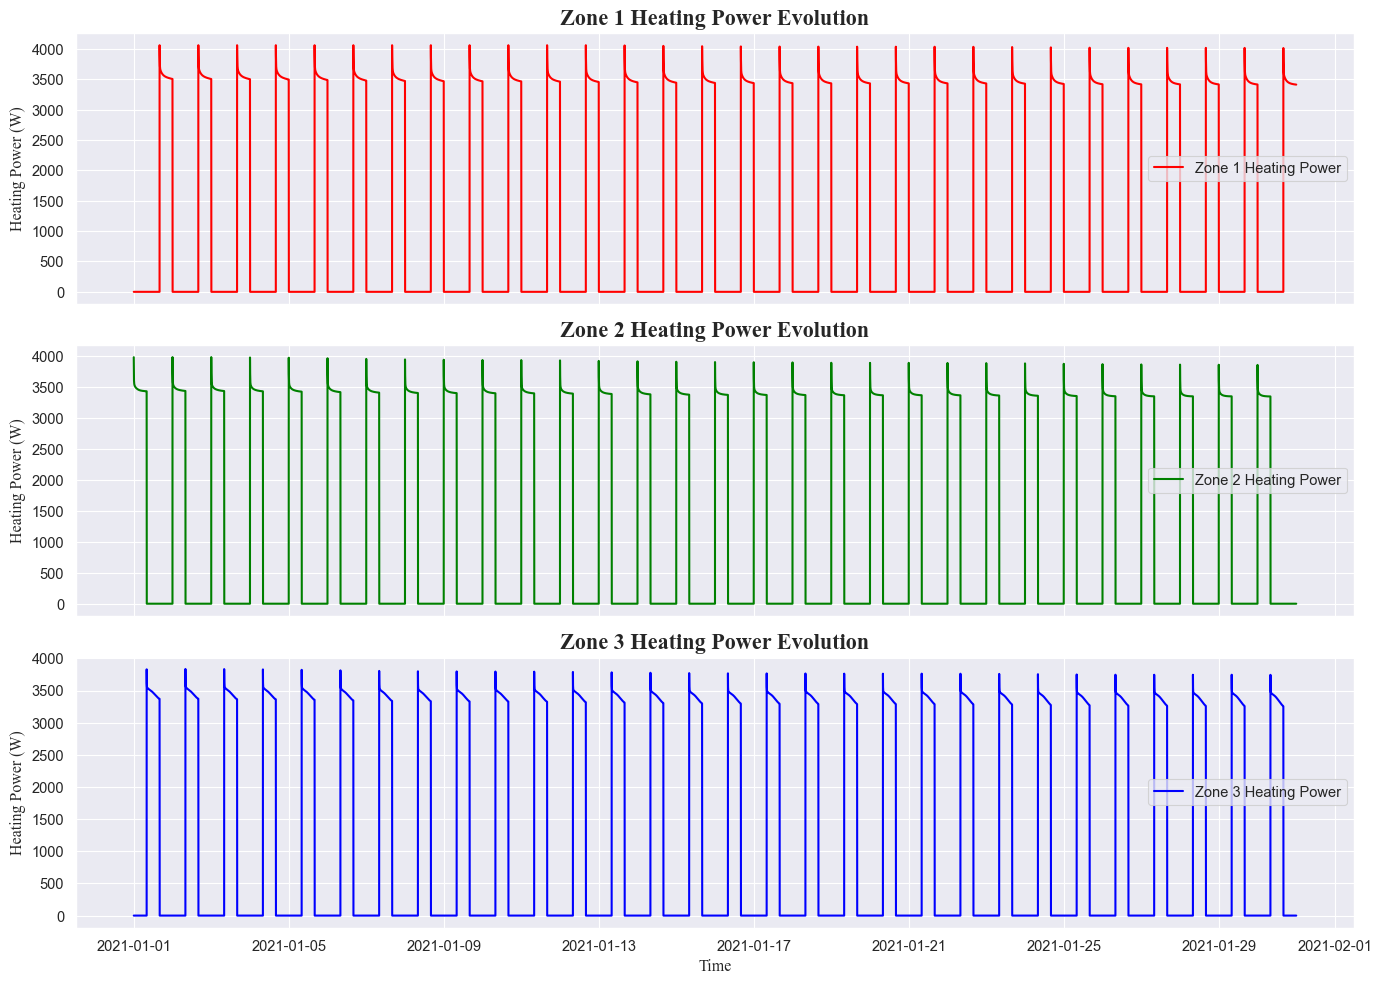

In [701]:

import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot for Zone 1
axs[0].plot(df.index, df['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='best')
axs[0].set_title('Zone 1 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 2
axs[1].plot(df.index, df['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='best')
axs[1].set_title('Zone 2 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

# Plot for Zone 3
axs[2].plot(df.index, df['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='best')
axs[2].set_title('Zone 3 Heating Power Evolution', fontname="Times New Roman", size=16, fontweight="bold")

plt.tight_layout()
plt.show()

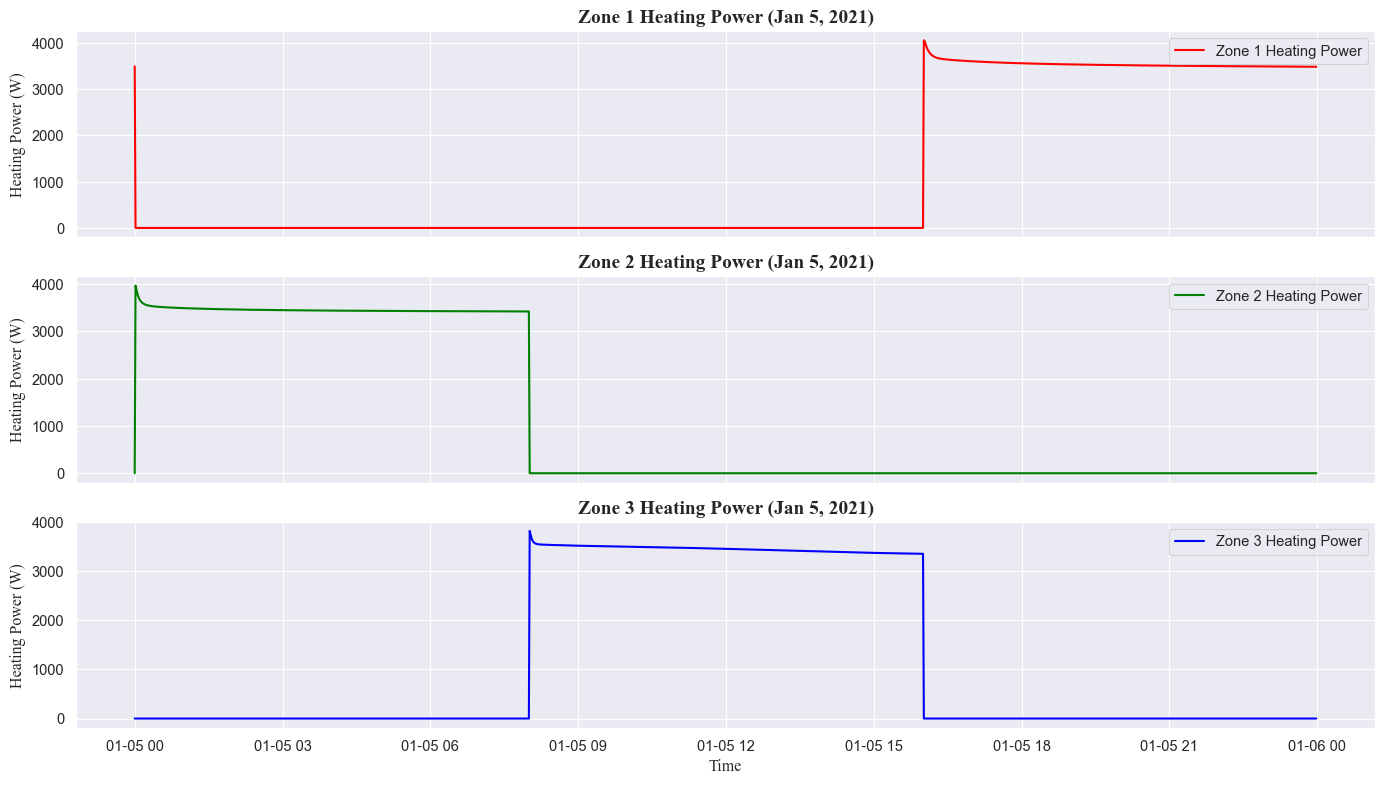

In [702]:
import matplotlib.pyplot as plt

# Make sure index is datetime
df.index = pd.to_datetime(df.index)

# Select 1 day (adjust date as needed)
one_day = df.loc['2021-01-05']

# Plot
fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Zone 1
axs[0].plot(one_day.index, one_day['Heating_Power_Z1'], color='red', linewidth=1.5, label='Zone 1 Heating Power')
axs[0].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[0].legend(loc='upper right')
axs[0].set_title('Zone 1 Heating Power (Jan 5, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

# Zone 2
axs[1].plot(one_day.index, one_day['Heating_Power_Z2'], color='green', linewidth=1.5, label='Zone 2 Heating Power')
axs[1].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[1].legend(loc='upper right')
axs[1].set_title('Zone 2 Heating Power (Jan 5, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

# Zone 3
axs[2].plot(one_day.index, one_day['Heating_Power_Z3'], color='blue', linewidth=1.5, label='Zone 3 Heating Power')
axs[2].set_ylabel('Heating Power (W)', fontname="Times New Roman")
axs[2].set_xlabel('Time', fontname="Times New Roman")
axs[2].legend(loc='upper right')
axs[2].set_title('Zone 3 Heating Power (Jan 5, 2021)', fontname="Times New Roman", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


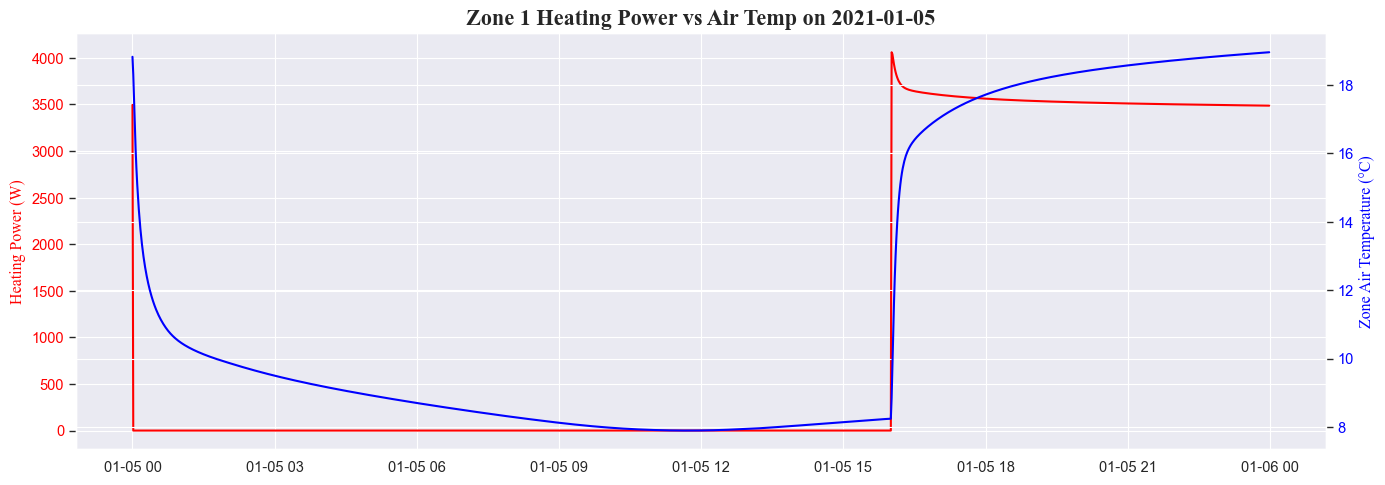

In [703]:
import matplotlib.pyplot as plt

# Make sure your datetime is the index
df.index = pd.to_datetime(df.index)

# Select one day (adjust date here)
day = '2021-01-05'
df_day = df.loc[day]

# Plot Heating Power and Zone Temp
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot Heating Power (left axis)
ax1.plot(df_day.index, df_day['Heating_Power_Z1'], color='red', label='Zone 1 Heating Power (W)', linewidth=1.5)
ax1.set_ylabel('Heating Power (W)', color='red', fontname="Times New Roman")
ax1.tick_params(axis='y', labelcolor='red')

# Plot Zone Temp (right axis)
ax2 = ax1.twinx()
ax2.plot(df_day.index, df_day['North_Zone_Air_Temperature'], color='blue', label='Zone 1 Air Temperature (°C)', linewidth=1.5)
ax2.set_ylabel('Zone Air Temperature (°C)', color='blue', fontname="Times New Roman")
ax2.tick_params(axis='y', labelcolor='blue')

# Titles and legend
plt.title(f'Zone 1 Heating Power vs Air Temp on {day}', fontname="Times New Roman", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()



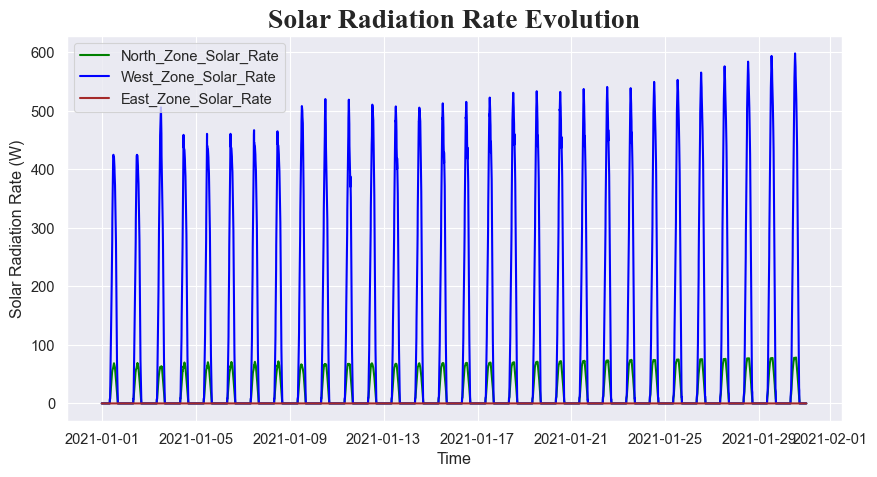

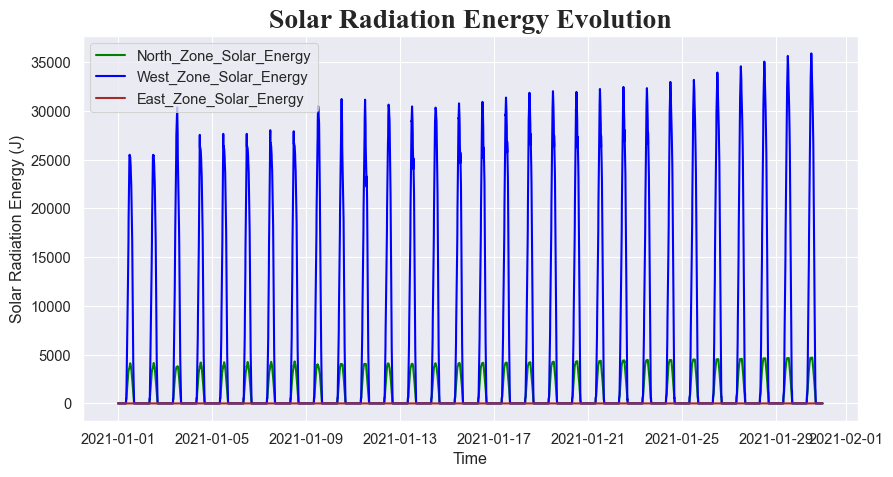

In [130]:
import matplotlib.pyplot as plt

# Plot Solar Radiation Rate
plt.figure(figsize=(10, 5))
for zone, color in zip(['North_Zone_Solar_Rate', 'West_Zone_Solar_Rate', 'East_Zone_Solar_Rate'], ['green', 'blue', 'brown']):
    plt.plot(plot_data.index, plot_data[zone], color=color, linewidth=1.5, label=zone)
plt.ylabel('Solar Radiation Rate (W)')
plt.xlabel('Time')
plt.legend(loc='best')
plt.title('Solar Radiation Rate Evolution', fontname="Times New Roman", size=20, fontweight="bold")
plt.show()

# Plot Solar Radiation Energy
plt.figure(figsize=(10, 5))
for zone, color in zip(['North_Zone_Solar_Energy', 'West_Zone_Solar_Energy', 'East_Zone_Solar_Energy'], ['green', 'blue', 'brown']):
    plt.plot(plot_data.index, plot_data[zone], color=color, linewidth=1.5, label=zone)
plt.ylabel('Solar Radiation Energy (J)')
plt.xlabel('Time')
plt.legend(loc='best')
plt.title('Solar Radiation Energy Evolution', fontname="Times New Roman", size=20, fontweight="bold")
plt.show()


<>:278: SyntaxWarning: invalid escape sequence '\P'
<>:278: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_25604\2321080192.py:278: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)


[2.83366667 2.88733333 2.941      ... 3.78733333 3.78366667 3.78      ]
  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 7496.46842678002
        x: [ 3.645e+03  3.440e+03  3.379e+03  3.827e+02  1.900e+02
             5.462e+03  0.000e+00  3.514e+02  0.000e+00  6.444e+00]
      nit: 119
      jac: [ 0.000e+00  9.095e-05  0.000e+00 -1.819e-04  5.457e-04
             0.000e+00  1.588e+01 -3.638e-04  6.239e+02  1.819e-03]
     nfev: 1606
     njev: 146
 hess_inv: <10x10 LbfgsInvHessProduct with dtype=float64>
Optimized Parameters:
C1: 3645.151414812023, C2: 3440.007175548048, C3: 3378.8166612474474
K12: 382.67308634068644, K10: 189.95883942266346, K23: 5461.8988628025745, K20: 0.0, K30: 351.43246958158204
D1: 0.0, D2: 6.443714930522341, D3 (fixed): 0
C1: 3645.151414812023
C2: 3440.007175548048
C3: 3378.8166612474474
K12: 382.67308634068644
K10: 189.95883942266346
K23: 5461.8988628025745
K20: 0.0
K30: 351.43246958158204
D1: 0.0
D2: 6.443714

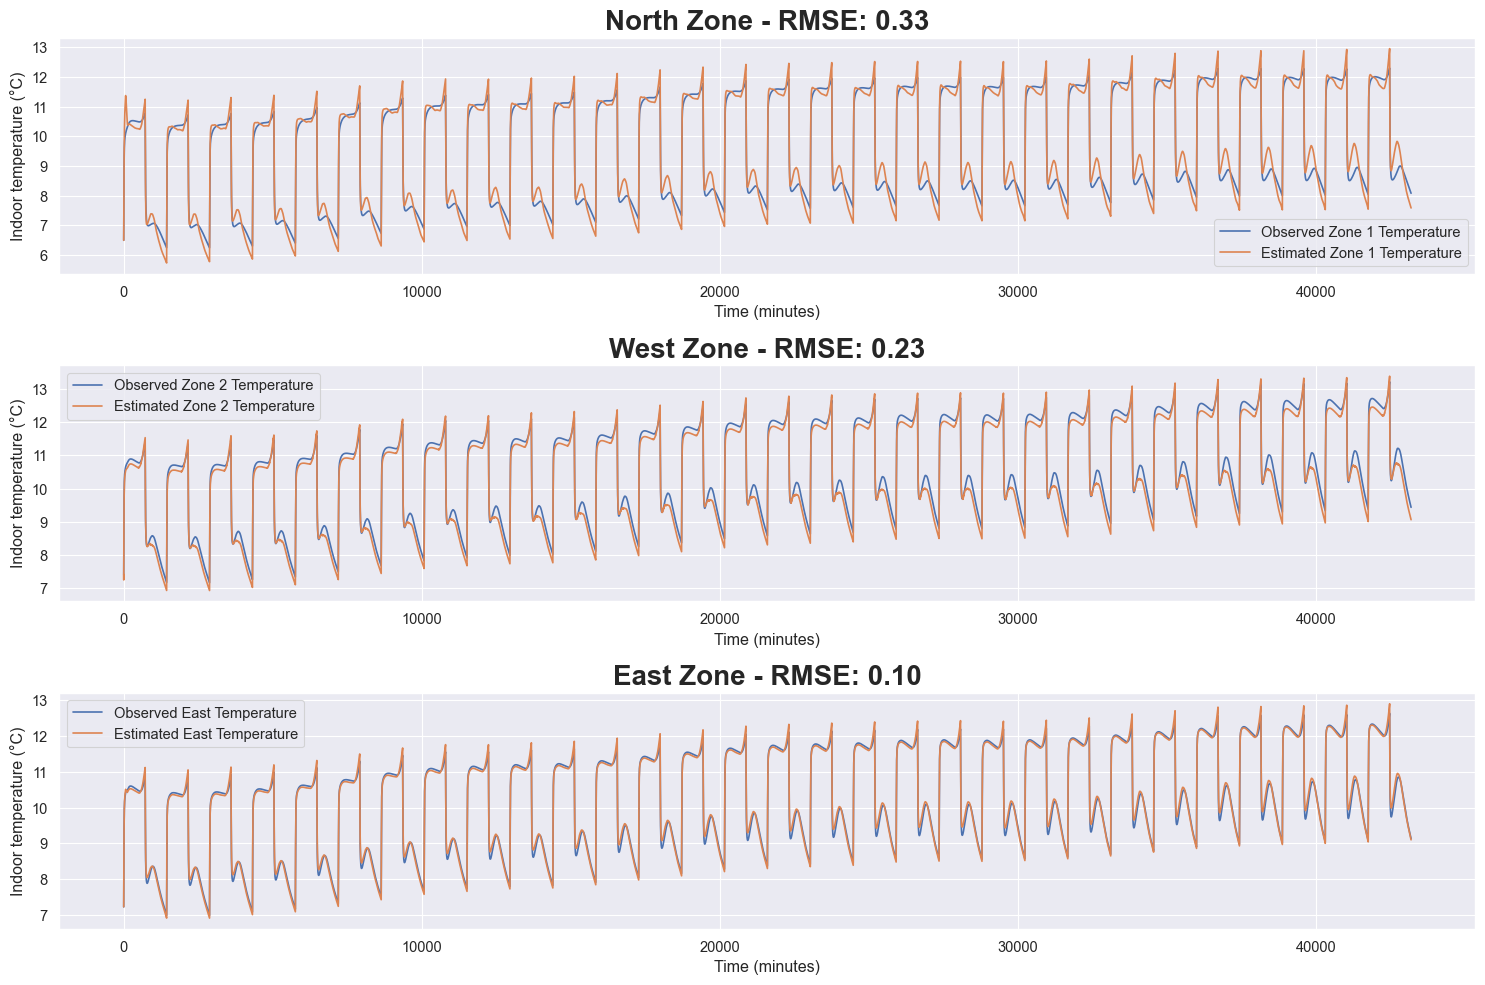

In [40]:


# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)
















from scipy.optimize import minimize

# Define the cost function using your variable names
def custom_cost(theta):
    C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
    D3 = 0  # fixed

    est_zone1 = np.zeros(num_steps)
    est_zone2 = np.zeros(num_steps)
    est_zone3 = np.zeros(num_steps)

    est_zone1[0] = zone1[0]
    est_zone2[0] = zone2[0]
    est_zone3[0] = zone3[0]

    for i in range(1, num_steps):
        try:
            est_zone1[i] = est_zone1[i-1] + (K12*(zone2[i-1] - est_zone1[i-1]) + K10*(T_outdoor[i-1] - est_zone1[i-1]) + U1[i-1] + D1*NS1[i-1])/C1 * dt
            est_zone2[i] = est_zone2[i-1] + (K12*(zone1[i-1] - est_zone2[i-1]) + K23*(zone3[i-1] - est_zone2[i-1]) + K20*(T_outdoor[i-1] - est_zone2[i-1]) + U2[i-1] + D2*WS2[i-1])/C2 * dt
            est_zone3[i] = est_zone3[i-1] + (K23*(zone2[i-1] - est_zone3[i-1]) + K30*(T_outdoor[i-1] - est_zone3[i-1]) + U3[i-1] + D3*ES3[i-1])/C3 * dt
        except:
            return 1e10

        # Stop early if value explodes
        if not np.all(np.isfinite([est_zone1[i], est_zone2[i], est_zone3[i]])):
            return 1e10
        if max(abs(est_zone1[i]), abs(est_zone2[i]), abs(est_zone3[i])) > 1e4:
            return 1e10
    # Sum of squared errors
    return np.sum((zone1 - est_zone1)**2) + np.sum((zone2 - est_zone2)**2) + np.sum((zone3 - est_zone3)**2)

# Initial guess and bounds
#initial_guess = np.ones(10)
initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]
theta = [C1, C2, C3, K12, K10, K23, K20, K30, D1, D2]


bounds = [(0, None)] * 10  # Non-negative constraints

# Run the minimization
result = minimize(custom_cost, initial_guess, bounds=bounds, method='L-BFGS-B')
print(result)
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = result.x
D3 = 0  # still fixed

print("Optimized Parameters:")
print(f"C1: {C1}, C2: {C2}, C3: {C3}")
print(f"K12: {K12}, K10: {K10}, K23: {K23}, K20: {K20}, K30: {K30}")
print(f"D1: {D1}, D2: {D2}, D3 (fixed): {D3}")




















# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

#print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")


In [38]:
print(result)

  message: ABNORMAL_TERMINATION_IN_LNSRCH
  success: False
   status: 2
      fun: nan
        x: [ 1.420e+02  5.226e+02  1.789e+02  1.138e+02  1.235e+02
             1.090e+01  2.754e+03  2.457e+03  1.100e+00  1.700e+00]
      nit: 0
      jac: [       nan        nan        nan        nan        nan
                   nan        nan        nan        nan        nan]
     nfev: 231
     njev: 21
 hess_inv: <10x10 LbfgsInvHessProduct with dtype=float64>


In [29]:
estimated_zone2

array([   7.42489311,  847.79630227, -837.7046068 , ...,           nan,
                 nan,           nan])

In [42]:


# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)















import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# Define your model-based cost function
def custom_cost(theta):
    C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
    D3 = 0

    est_zone1 = np.zeros(num_steps)
    est_zone2 = np.zeros(num_steps)
    est_zone3 = np.zeros(num_steps)

    est_zone1[0] = zone1[0]
    est_zone2[0] = zone2[0]
    est_zone3[0] = zone3[0]

    for i in range(1, num_steps):
        try:
            est_zone1[i] = est_zone1[i-1] + (K12*(zone2[i-1] - est_zone1[i-1]) + K10*(T_outdoor[i-1] - est_zone1[i-1]) + U1[i-1] + D1*NS1[i-1]) / C1 * dt
            est_zone2[i] = est_zone2[i-1] + (K12*(zone1[i-1] - est_zone2[i-1]) + K23*(zone3[i-1] - est_zone2[i-1]) + K20*(T_outdoor[i-1] - est_zone2[i-1]) + U2[i-1] + D2*WS2[i-1]) / C2 * dt
            est_zone3[i] = est_zone3[i-1] + (K23*(zone2[i-1] - est_zone3[i-1]) + K30*(T_outdoor[i-1] - est_zone3[i-1]) + U3[i-1]) / C3 * dt
        except:
            return 1e10

        if not np.all(np.isfinite([est_zone1[i], est_zone2[i], est_zone3[i]])):
            return 1e10
    return np.sum((zone1 - est_zone1)**2 + (zone2 - est_zone2)**2 + (zone3 - est_zone3)**2)

initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]

bounds = [(1e-3, None)] * 10




[2.83366667 2.88733333 2.941      ... 3.78733333 3.78366667 3.78      ]


In [44]:
res_trust = minimize(custom_cost, initial_guess, bounds=bounds, method='trust-constr', options={'verbose': 1})


C:\Users\USER\anaconda3\Lib\site-packages\scipy\optimize\_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 219, function evaluations: 2761, CG iterations: 1087, optimality: 1.85e-05, constraint violation: 0.00e+00, execution time: 1.3e+03 s.


In [45]:

print("🔹 Trust-Constr Result:")
print(res_trust)

C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = res_trust.x
D3 = 0  # still fixed

🔹 Trust-Constr Result:
           message: `xtol` termination condition is satisfied.
           success: True
            status: 2
               fun: 7497.108278412547
                 x: [ 3.645e+03  3.438e+03  3.379e+03  3.827e+02  1.900e+02
                      5.462e+03  1.000e-03  3.514e+02  1.000e-03  6.444e+00]
               nit: 219
              nfev: 2761
              njev: 251
              nhev: 0
          cg_niter: 1087
      cg_stop_cond: 2
              grad: [-6.698e-08  8.166e-07  1.788e-06 -1.435e-06  8.675e-06
                     -2.458e-07  1.588e+01 -6.947e-07  6.241e+02  1.894e-05]
   lagrangian_grad: [-6.698e-08  8.166e-07  1.788e-06 -1.435e-06  8.675e-06
                     -2.458e-07  1.190e-13 -6.947e-07  0.000e+00  1.850e-05]
            constr: [array([ 3.645e+03,  3.438e+03,  3.379e+03,  3.827e+02,
                            1.900e+02,  5.462e+03,  1.000e-03,  3.514e+02,
                            1.000e-03,  6.444e+00])]
               jac: [<10

In [ ]:
from cyipopt import minimize_ipopt

res_ipopt = minimize_ipopt(custom_cost, x0=initial_guess, bounds=bounds)


In [ ]:
import pyomo.environ as pyo

model = pyo.ConcreteModel()
model.theta = pyo.Var(range(10), domain=pyo.NonNegativeReals, initialize=lambda m, i: initial_guess[i])

def obj_rule(m):
    x = [m.theta[i]() for i in range(10)]
    return custom_cost(x)

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

solver = pyo.SolverFactory('ipopt')
solver.options['tol'] = 1e-6
solver.options['max_iter'] = 500
solver.solve(model, tee=True)

opt_params_pyomo = [pyo.value(model.theta[i]) for i in range(10)]


In [ ]:
res_slsqp = minimize(custom_cost, initial_guess, method='SLSQP', bounds=bounds, options={'disp': True})


Optimized Parameters:
C1: 3645.1494131494273, C2: 3438.1488874774095, C3: 3378.9046445570634
K12: 382.6749038243343, K10: 189.96135924354493, K23: 5461.820792786003, K20: 0.0010000865397175032, K30: 351.4322676657587
D1: 0.0010000023363694417, D2: 6.443662232675653, D3 (fixed): 0
C1: 3645.1494131494273
C2: 3438.1488874774095
C3: 3378.9046445570634
K12: 382.6749038243343
K10: 189.96135924354493
K23: 5461.820792786003
K20: 0.0010000865397175032
K30: 351.4322676657587
D1: 0.0010000023363694417
D2: 6.443662232675653


<>:168: SyntaxWarning: invalid escape sequence '\P'
<>:168: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_25604\1640662192.py:168: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)


RMSE for Zone 1: 0.33
RMSE for Zone 2: 0.23
RMSE for Zone 3: 0.10


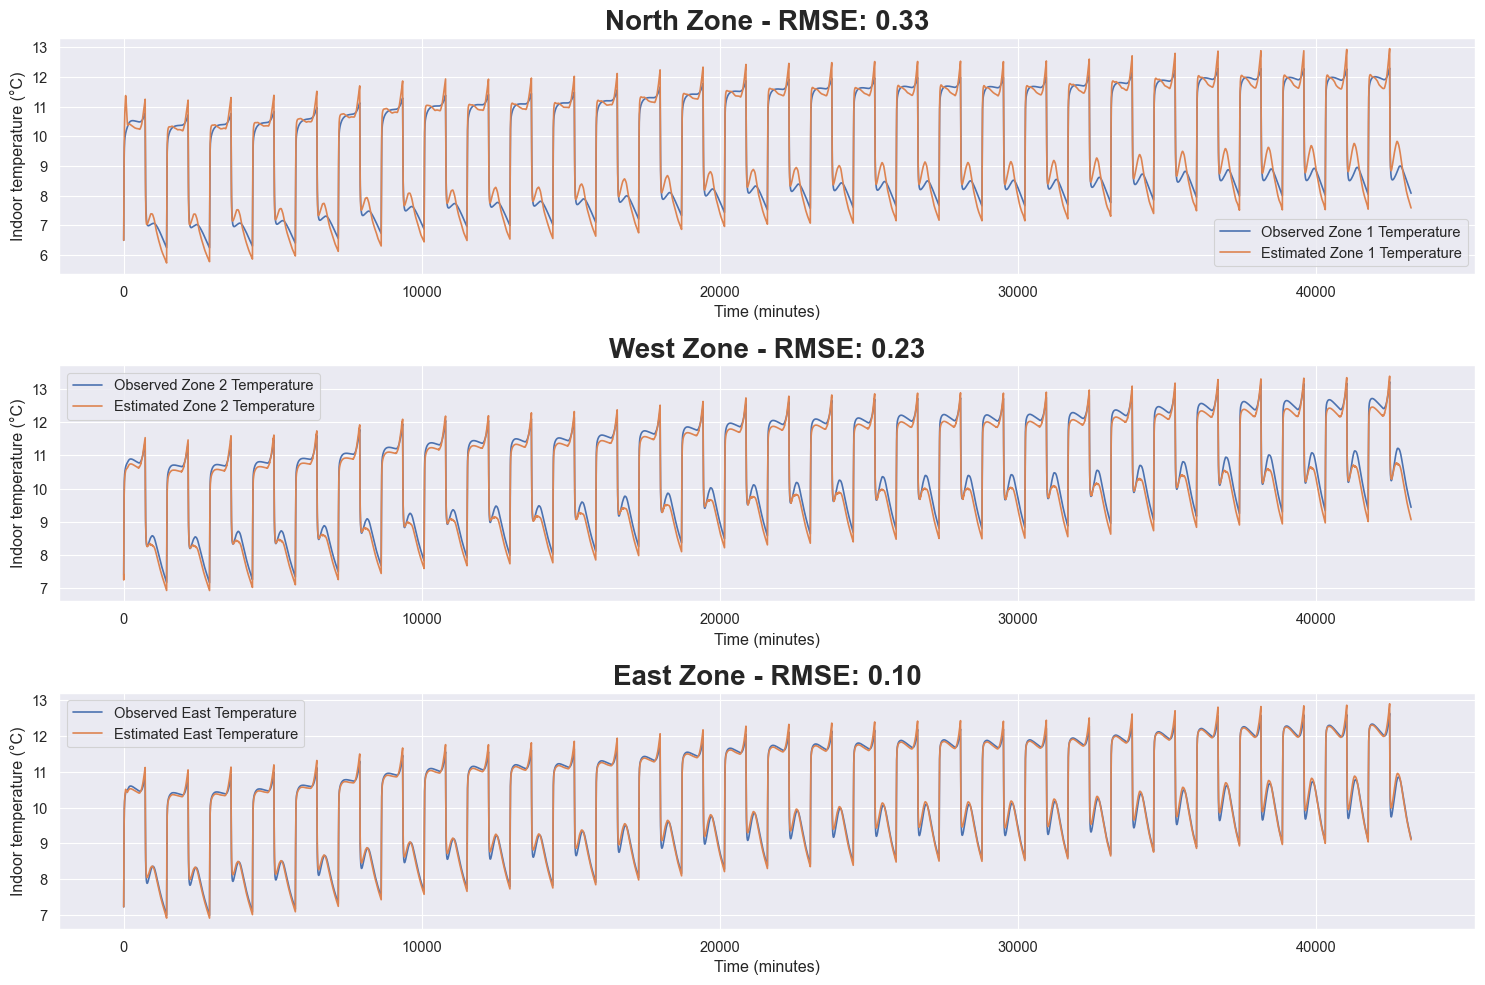

In [46]:




print("Optimized Parameters:")
print(f"C1: {C1}, C2: {C2}, C3: {C3}")
print(f"K12: {K12}, K10: {K10}, K23: {K23}, K20: {K20}, K30: {K30}")
print(f"D1: {D1}, D2: {D2}, D3 (fixed): {D3}")




















# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

#print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")


In [76]:


# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)















import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# Define your model-based cost function
def custom_cost(theta):
    C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
    D3 = 0

    est_zone1 = np.zeros(num_steps)
    est_zone2 = np.zeros(num_steps)
    est_zone3 = np.zeros(num_steps)

    est_zone1[0] = zone1[0]
    est_zone2[0] = zone2[0]
    est_zone3[0] = zone3[0]

    for i in range(1, num_steps):
        try:
            est_zone1[i] = est_zone1[i-1] + (K12*(zone2[i-1] - est_zone1[i-1]) + K10*(T_outdoor[i-1] - est_zone1[i-1]) + U1[i-1] + D1*NS1[i-1]) / C1 * dt
            est_zone2[i] = est_zone2[i-1] + (K12*(zone1[i-1] - est_zone2[i-1]) + K23*(zone3[i-1] - est_zone2[i-1]) + K20*(T_outdoor[i-1] - est_zone2[i-1]) + U2[i-1] + D2*WS2[i-1]) / C2 * dt
            est_zone3[i] = est_zone3[i-1] + (K23*(zone2[i-1] - est_zone3[i-1]) + K30*(T_outdoor[i-1] - est_zone3[i-1]) + U3[i-1]) / C3 * dt
        except:
            return 1e10

        if not np.all(np.isfinite([est_zone1[i], est_zone2[i], est_zone3[i]])):
            return 1e10
    return np.sum((zone1 - est_zone1)**2 + (zone2 - est_zone2)**2 + (zone3 - est_zone3)**2)

initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]

bounds = [(1e-3, None)] * 10




[2.83366667 2.88733333 2.941      ... 3.78733333 3.78366667 3.78      ]


In [92]:
res_slsqp = minimize(custom_cost, initial_guess, method='SLSQP', bounds=bounds, options={'disp': True})


C:\Users\USER\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
C:\Users\USER\anaconda3\Lib\site-packages\scipy\optimize\_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 7497.108364612603
            Iterations: 70
            Function evaluations: 796
            Gradient evaluations: 70


In [88]:
from cyipopt import minimize_ipopt

res_ipopt = minimize_ipopt(custom_cost, x0=initial_guess, bounds=bounds)


ModuleNotFoundError: No module named 'cyipopt'

In [74]:
# Initial guess
initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]

# Unpack values from the list into named variables
C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = initial_guess

# Now you can use the variables directly
print("D1:", D1)
print("C1:", C1)



D1: 1.1
C1: 3661.9


In [93]:

print("🔹 Trust-Constr Result:")
print(res_slsqp)

C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = res_slsqp.x
D3 = 0  # still fixed

🔹 Trust-Constr Result:
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 7497.108364612603
       x: [ 3.645e+03  3.439e+03  3.380e+03  3.827e+02  1.900e+02
            5.464e+03  1.000e-03  3.515e+02  1.000e-03  6.446e+00]
     nit: 70
     jac: [ 6.104e-05 -6.104e-05  0.000e+00  0.000e+00 -1.526e-03
            6.104e-05  1.588e+01 -3.662e-04  6.241e+02  1.996e-02]
    nfev: 796
    njev: 70


Optimized Parameters:
C1: 3645.470029849785, C2: 3439.171805444786, C3: 3380.2566321436816
K12: 382.6784782473966, K10: 189.9615620547499, K23: 5463.7927015591995, K20: 0.0010000021503030014, K30: 351.5248254422823
D1: 0.001, D2: 6.446098383524394, D3 (fixed): 0
C1: 3645.470029849785
C2: 3439.171805444786
C3: 3380.2566321436816
K12: 382.6784782473966
K10: 189.9615620547499
K23: 5463.7927015591995
K20: 0.0010000021503030014
K30: 351.5248254422823
D1: 0.001
D2: 6.446098383524394


<>:168: SyntaxWarning: invalid escape sequence '\P'
<>:168: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_25604\1640662192.py:168: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)


RMSE for Zone 1: 0.33
RMSE for Zone 2: 0.23
RMSE for Zone 3: 0.10


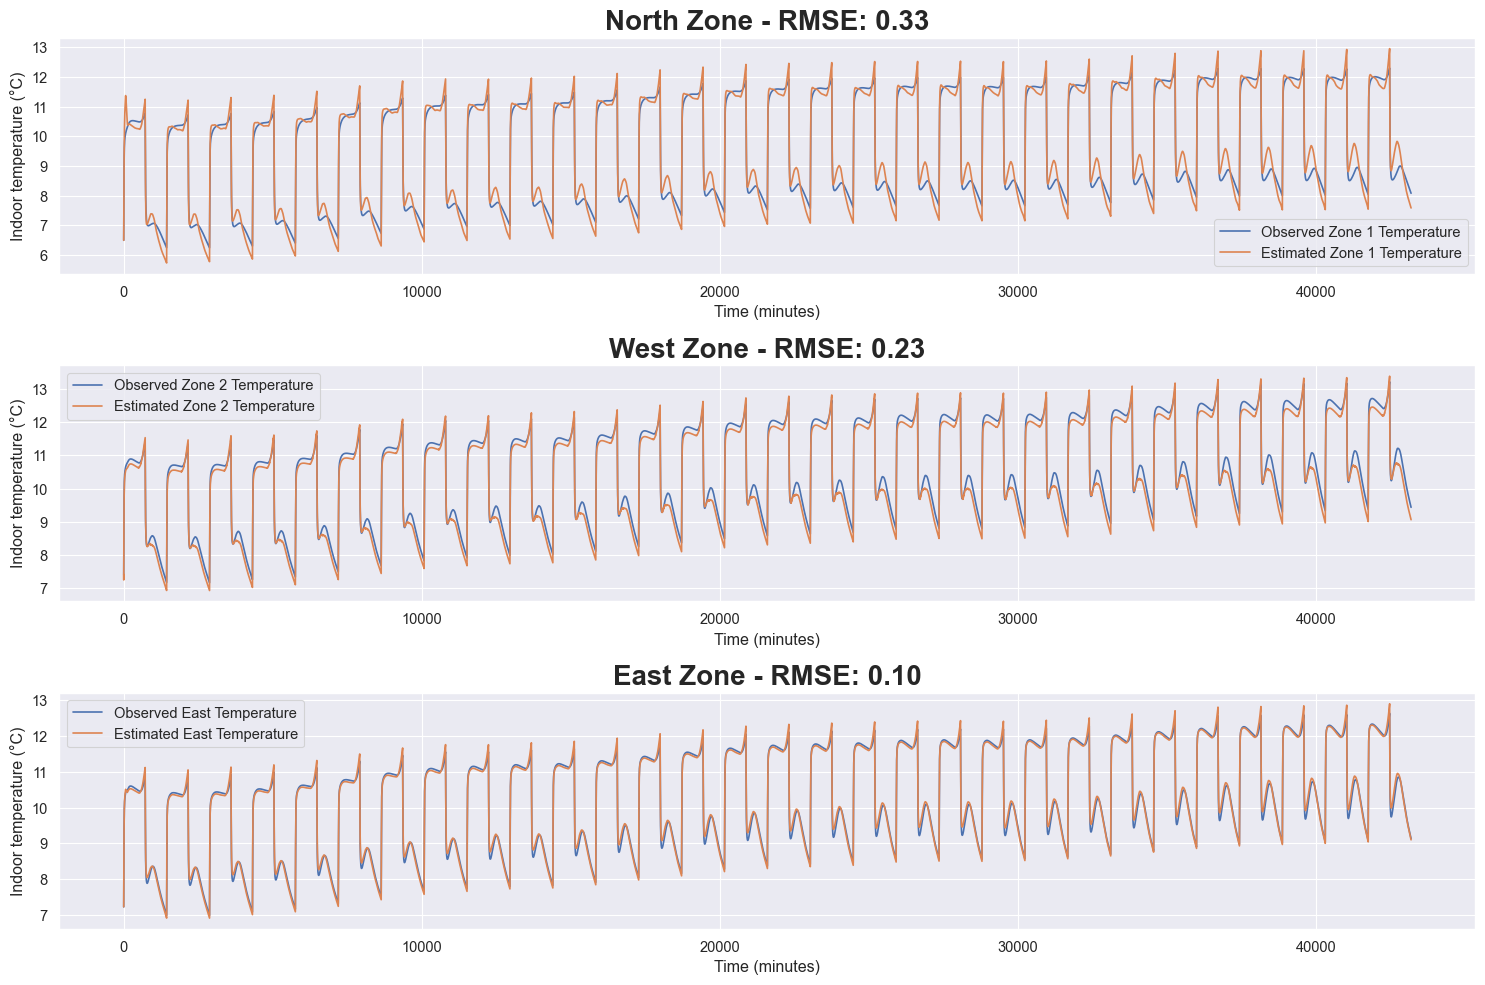

In [94]:




print("Optimized Parameters:")
print(f"C1: {C1}, C2: {C2}, C3: {C3}")
print(f"K12: {K12}, K10: {K10}, K23: {K23}, K20: {K20}, K30: {K30}")
print(f"D1: {D1}, D2: {D2}, D3 (fixed): {D3}")




















# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

#print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")


In [98]:
print(f"D2: {D2}")

D2: 6.446098383524394


<>:289: SyntaxWarning: invalid escape sequence '\P'
<>:289: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_25604\1287139511.py:289: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)


[2.83366667 2.88733333 2.941      ... 3.78733333 3.78366667 3.78      ]
`xtol` termination condition is satisfied.
Number of iterations: 235, function evaluations: 2244, CG iterations: 968, optimality: 1.60e-05, constraint violation: 0.00e+00, execution time: 9.5e+02 s.
🔹 Trust-Constr Result:
           message: `xtol` termination condition is satisfied.
           success: True
            status: 2
               fun: 14724.207249723804
                 x: [ 3.726e+03  2.347e+03  2.139e+03  3.516e+02  1.864e+02
                      1.000e+03  1.524e+01  1.355e+02  1.000e-03  1.522e+00]
               nit: 235
              nfev: 2244
              njev: 204
              nhev: 0
          cg_niter: 968
      cg_stop_cond: 4
              grad: [ 3.276e-07 -5.201e-08  1.941e-06  0.000e+00 -6.547e-07
                     -1.350e+01  1.602e-05  1.802e-06  6.288e+02  0.000e+00]
   lagrangian_grad: [ 3.276e-07 -5.201e-08  1.941e-06 -5.825e-12 -6.547e-07
                     -2.842e-14  1

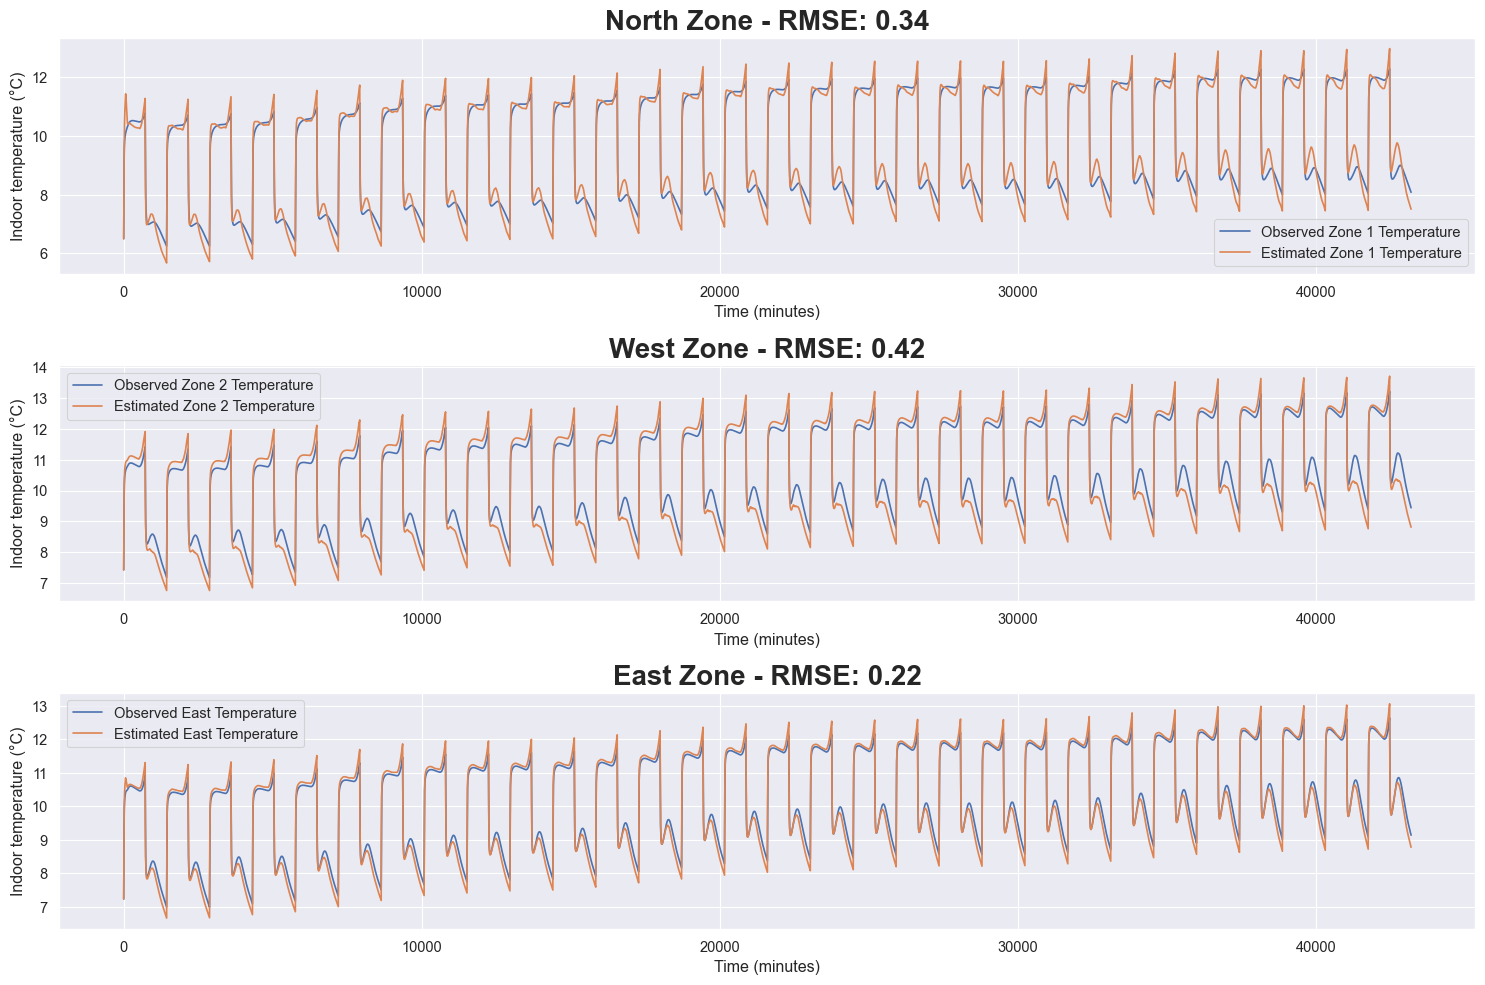

In [100]:


# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)















import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# Define your model-based cost function
def custom_cost(theta):
    C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
    D3 = 0

    est_zone1 = np.zeros(num_steps)
    est_zone2 = np.zeros(num_steps)
    est_zone3 = np.zeros(num_steps)

    est_zone1[0] = zone1[0]
    est_zone2[0] = zone2[0]
    est_zone3[0] = zone3[0]

    for i in range(1, num_steps):
        try:
            est_zone1[i] = est_zone1[i-1] + (K12*(zone2[i-1] - est_zone1[i-1]) + K10*(T_outdoor[i-1] - est_zone1[i-1]) + U1[i-1] + D1*NS1[i-1]) / C1 * dt
            est_zone2[i] = est_zone2[i-1] + (K12*(zone1[i-1] - est_zone2[i-1]) + K23*(zone3[i-1] - est_zone2[i-1]) + K20*(T_outdoor[i-1] - est_zone2[i-1]) + U2[i-1] + D2*WS2[i-1]) / C2 * dt
            est_zone3[i] = est_zone3[i-1] + (K23*(zone2[i-1] - est_zone3[i-1]) + K30*(T_outdoor[i-1] - est_zone3[i-1]) + U3[i-1]) / C3 * dt
        except:
            return 1e10

        if not np.all(np.isfinite([est_zone1[i], est_zone2[i], est_zone3[i]])):
            return 1e10
    return np.sum((zone1 - est_zone1)**2 + (zone2 - est_zone2)**2 + (zone3 - est_zone3)**2)

initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]

#bounds = [(1e-3, None)] * 10
bounds = [
    (1e-3, None),  # C1
    (1e-3, None),  # C2
    (1e-3, None),  # C3
    (1e-3, None),  # K12
    (1e-3, None),  # K10
    (1e-3, 1000),  # K23 ≤ 1000
    (1e-3, None),  # K20
    (1e-3, None),  # K30
    (1e-3, 2),  # D1 > 0
    (1e-3, 2),  # D2 > 0
]

res_trust = minimize(custom_cost, initial_guess, bounds=bounds, method='trust-constr', options={'verbose': 1})


print("🔹 Trust-Constr Result:")
print(res_trust)

C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = res_trust.x
D3 = 0  # still fixed




print("Optimized Parameters:")
print(f"C1: {C1}, C2: {C2}, C3: {C3}")
print(f"K12: {K12}, K10: {K10}, K23: {K23}, K20: {K20}, K30: {K30}")
print(f"D1: {D1}, D2: {D2}, D3 (fixed): {D3}")




















# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

#print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")



<>:289: SyntaxWarning: invalid escape sequence '\P'
<>:289: SyntaxWarning: invalid escape sequence '\P'
C:\Users\USER\AppData\Local\Temp\ipykernel_25604\3075388937.py:289: SyntaxWarning: invalid escape sequence '\P'
  df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)


[2.83366667 2.88733333 2.941      ... 3.78733333 3.78366667 3.78      ]


C:\Users\USER\anaconda3\Lib\site-packages\scipy\optimize\_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 223, function evaluations: 2376, CG iterations: 841, optimality: 1.38e-05, constraint violation: 0.00e+00, execution time: 1e+03 s.
🔹 Trust-Constr Result:
           message: `xtol` termination condition is satisfied.
           success: True
            status: 2
               fun: 14921.15421168792
                 x: [ 3.628e+03  2.347e+03  2.139e+03  3.518e+02  1.872e+02
                      1.000e+03  1.522e+01  1.355e+02  3.000e-01  1.522e+00]
               nit: 223
              nfev: 2376
              njev: 216
              nhev: 0
          cg_niter: 841
      cg_stop_cond: 4
              grad: [-2.019e-07 -9.362e-07  7.991e-07  1.735e-06  6.522e-07
                     -1.351e+01  8.019e-06  0.000e+00  6.885e+02  8.021e-05]
   lagrangian_grad: [-2.019e-07 -9.362e-07  7.991e-07  1.735e-06  6.521e-07
                     -1.723e-13  7.985e-06 -1.511e-11  0.000e+00  1.381e-05]
            constr: [array([ 3.6

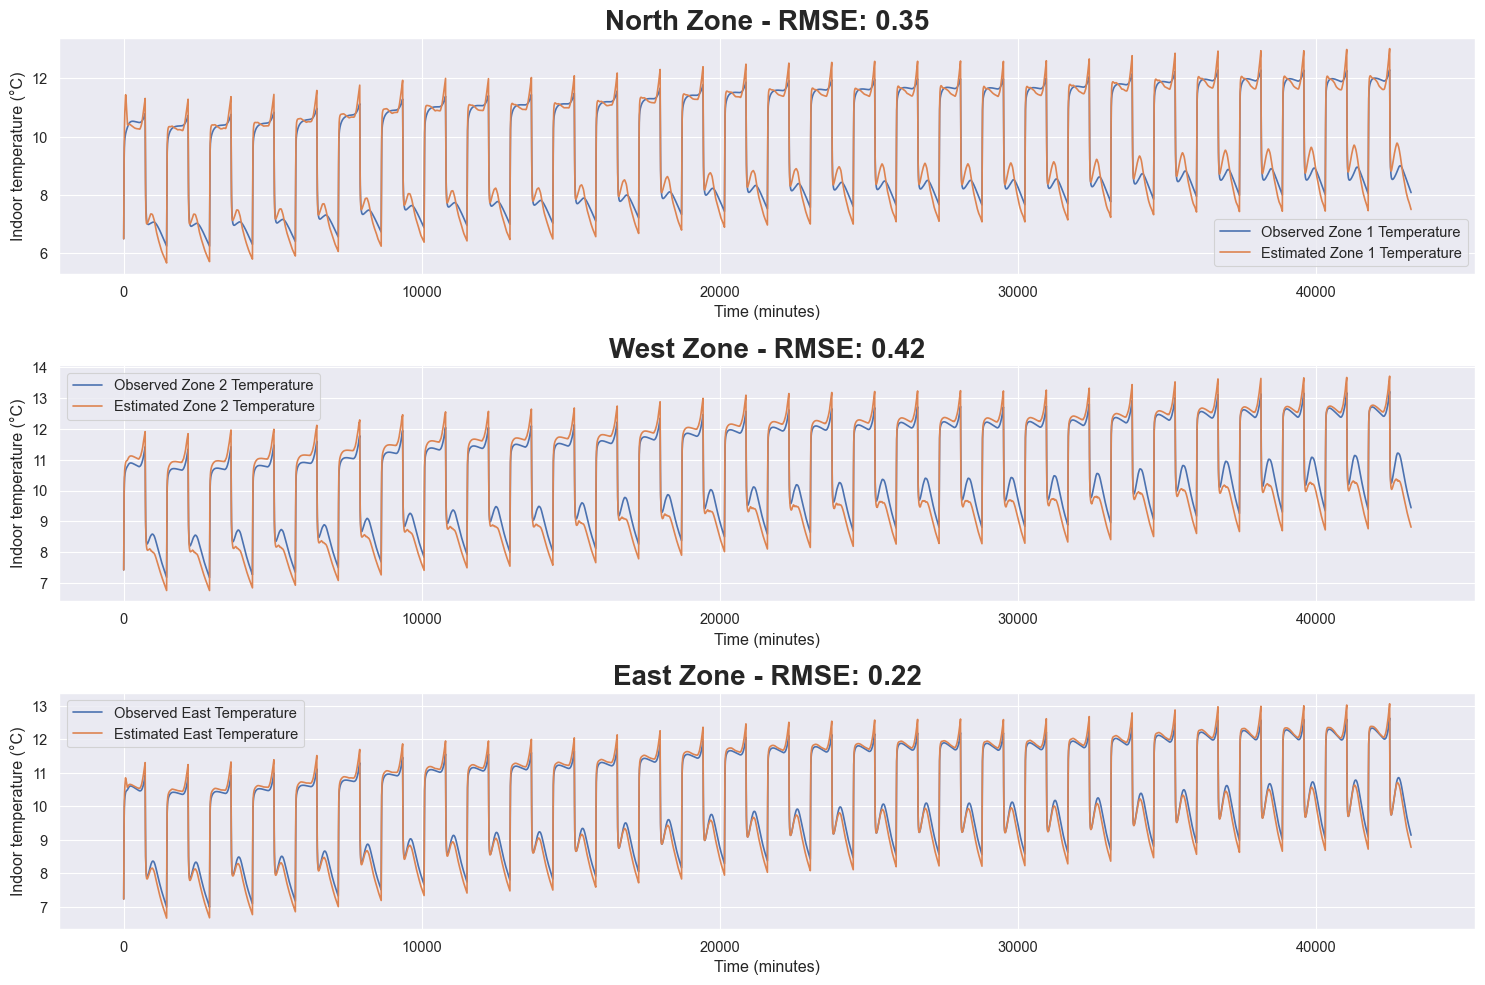

In [102]:


# Read the data from CSV files
#filename =  r"C:\Users\onyej\OneDrive\Desktop\Documents\Experiments Folder\modifiedversion\modifiedversion2\Resultssimulation_results_2024-06-08_02-07-16.csv"
df = pd.read_csv(filename)

# Define time step if not explicitly given (assuming uniform steps)
time = df['time_steps'].values

#I added
#df['time_steps'] = np.arange(len(df))  # Recreate time steps
#time = df['time_steps'].values  # Extract again

#print(f"Verification Data Total Points 1111: {len(time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {time[-1]}")
num_steps = len(time)
dt = np.median(np.diff(time))
dt=1



# Extracting data
T_outdoor = df['Ambient_Temperature'].values
print(T_outdoor)
zone1 = df['North_Zone_Air_Temperature'].values  
zone2 = df['West_Zone_Air_Temperature'].values 
zone3 = df['East_Zone_Air_Temperature'].values 
U1 = df['Heating_Power_Z1'].values
U2 = df['Heating_Power_Z2'].values
U3 = df['Heating_Power_Z3'].values

#new radiation power
NS1 = df['North_Zone_Solar_Rate'].values
WS2 = df['West_Zone_Solar_Rate'].values
ES3 = df['East_Zone_Solar_Rate'].values

# Compute temperature derivatives
dT1_dt = np.gradient(zone1, dt)
dT2_dt = np.gradient(zone2, dt)
dT3_dt = np.gradient(zone3, dt)















import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# Define your model-based cost function
def custom_cost(theta):
    C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = theta
    D3 = 0

    est_zone1 = np.zeros(num_steps)
    est_zone2 = np.zeros(num_steps)
    est_zone3 = np.zeros(num_steps)

    est_zone1[0] = zone1[0]
    est_zone2[0] = zone2[0]
    est_zone3[0] = zone3[0]

    for i in range(1, num_steps):
        try:
            est_zone1[i] = est_zone1[i-1] + (K12*(zone2[i-1] - est_zone1[i-1]) + K10*(T_outdoor[i-1] - est_zone1[i-1]) + U1[i-1] + D1*NS1[i-1]) / C1 * dt
            est_zone2[i] = est_zone2[i-1] + (K12*(zone1[i-1] - est_zone2[i-1]) + K23*(zone3[i-1] - est_zone2[i-1]) + K20*(T_outdoor[i-1] - est_zone2[i-1]) + U2[i-1] + D2*WS2[i-1]) / C2 * dt
            est_zone3[i] = est_zone3[i-1] + (K23*(zone2[i-1] - est_zone3[i-1]) + K30*(T_outdoor[i-1] - est_zone3[i-1]) + U3[i-1]) / C3 * dt
        except:
            return 1e10

        if not np.all(np.isfinite([est_zone1[i], est_zone2[i], est_zone3[i]])):
            return 1e10
    return np.sum((zone1 - est_zone1)**2 + (zone2 - est_zone2)**2 + (zone3 - est_zone3)**2)

initial_guess = [
    3661.9,  # C1
    2754.2,  # C2
    2456.7,  # C3
    142.0,   # K12
    178.9,   # K10
    522.6,   # K23
    113.8,   # K20
    123.5,   # K30
    1.1,     # D1
    1.7      # D2
]

#bounds = [(1e-3, None)] * 10
bounds = [
    (1e-3, None),  # C1
    (1e-3, None),  # C2
    (1e-3, None),  # C3
    (1e-3, None),  # K12
    (1e-3, None),  # K10
    (1e-3, 1000),  # K23 ≤ 1000
    (1e-3, None),  # K20
    (1e-3, None),  # K30
    (0.3, 2),  # D1 > 0
    (1e-3, 2),  # D2 > 0
]

res_trust = minimize(custom_cost, initial_guess, bounds=bounds, method='trust-constr', options={'verbose': 1})


print("🔹 Trust-Constr Result:")
print(res_trust)

C1, C2, C3, K12, K10, K23, K20, K30, D1, D2 = res_trust.x
D3 = 0  # still fixed




print("Optimized Parameters:")
print(f"C1: {C1}, C2: {C2}, C3: {C3}")
print(f"K12: {K12}, K10: {K10}, K23: {K23}, K20: {K20}, K30: {K30}")
print(f"D1: {D1}, D2: {D2}, D3 (fixed): {D3}")




















# Extract the identified parameters
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2, D3    = theta
#C1, C2, C3, K12, K10, K23, K20, K30,  D1, D2    = theta

#print(theta)

# Print the identified parameters
print(f"C1: {C1}")
print(f"C2: {C2}")
print(f"C3: {C3}")
print(f"K12: {K12}")
print(f"K10: {K10}")
print(f"K23: {K23}")
print(f"K20: {K20}")
print(f"K30: {K30}")
print(f"D1: {D1}")
print(f"D2: {D2}")
#print(f"D3: {D3}")


# Round each value to one decimal place
data_dict = {
    'K12': round(K12, 1), 
    'K23': round(K23, 1), 
    'K10': round(K10, 1), 
    'K20': round(K20, 1), 
    'K30': round(K30, 1), 
    'C1': round(C1, 1), 
    'C2': round(C2, 1), 
    'C3': round(C3, 1),
    'D1': round(D1, 1),
    'D2': round(D2, 1),
 #   'D3': round(D3, 1)
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame([data_dict])

# Specify the file path
Rc_Parameters = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\Parameter_Estimates.csv"

# Check if file exists and is not empty
if os.path.isfile(Rc_Parameters) and os.path.getsize(Rc_Parameters) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(Rc_Parameters, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(Rc_Parameters, mode='w', header=True, index=False)
    
#K12=K12+1000  
###############################################################################################################################    
D3=0 #just for measuring
######################################################################################################################    
# Calculate the estimated temperatures
estimated_zone1 = np.zeros(num_steps)
estimated_zone2 = np.zeros(num_steps)
estimated_zone3 = np.zeros(num_steps)

estimated_zone1[0] = zone1[0]  # Initial temperature for zone1
estimated_zone2[0] = zone2[0]  # Initial temperature for zone2
estimated_zone3[0] = zone3[0]  # Initial temperature for zone3

for i in range(1, num_steps):
    estimated_zone1[i] = estimated_zone1[i-1] + (K12*(zone2[i-1] - estimated_zone1[i-1]) + K10*(T_outdoor[i-1] - estimated_zone1[i-1]) + U1[i-1] + D1*NS1[i-1] )/C1 * dt 
    estimated_zone2[i] = estimated_zone2[i-1] + (K12*(zone1[i-1] - estimated_zone2[i-1]) + K23*(zone3[i-1] - estimated_zone2[i-1]) + K20*(T_outdoor[i-1] - estimated_zone2[i-1]) + U2[i-1] + D2*WS2[i-1] )/C2 * dt 
    estimated_zone3[i] = estimated_zone3[i-1] + (K23*(zone2[i-1] - estimated_zone3[i-1]) + K30*(T_outdoor[i-1] - estimated_zone3[i-1]) + U3[i-1]  + D3 * ES3[i-1])/C3 * dt 
    
    
rmse_y1 = np.sqrt(mean_squared_error(zone1, estimated_zone1))
rmse_y2 = np.sqrt(mean_squared_error(zone2, estimated_zone2))
rmse_y3 = np.sqrt(mean_squared_error(zone3, estimated_zone3))


print(f"RMSE for Zone 1: {rmse_y1:.2f}")
print(f"RMSE for Zone 2: {rmse_y2:.2f}")
print(f"RMSE for Zone 3: {rmse_y3:.2f}")


# Round each value to one decimal place
RMSE = {
    'RMSE Zone 1': rmse_y1, 
    'RMSE Zone 2': rmse_y2, 
    'RMSE Zone 3': rmse_y3
}

df = pd.DataFrame([RMSE])

# Specify the file path
RMSE = r"D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting\james\week4_solar_and_new_cost_function\DOF_change\RMSE.csv"


# Check if file exists and is not empty
if os.path.isfile(RMSE) and os.path.getsize(RMSE) > 0:
    # If file exists and is not empty, do not write header
    df.to_csv(RMSE, mode='a', header=False, index=False)
else:
    # If file doesn't exist or is empty, write header
    df.to_csv(RMSE, mode='w', header=True, index=False)




###########################################################################################################################################################################################################################
# Assuming `time` is an array or series that increments per minute, we trim all arrays to some number of minutes
minutes_to_plot = 2592000
if len(time) > minutes_to_plot:
    plot_time = time[:minutes_to_plot]
    plot_zone1 = zone1[:minutes_to_plot]
    plot_estimated_zone1 = estimated_zone1[:minutes_to_plot]
    plot_zone2 = zone2[:minutes_to_plot]
    plot_estimated_zone2 = estimated_zone2[:minutes_to_plot]
    plot_zone3 = zone3[:minutes_to_plot]
    plot_estimated_zone3 = estimated_zone3[:minutes_to_plot]
else:
    # Not enough data, use what we have
    plot_time = time
    plot_zone1 = zone1
    plot_estimated_zone1 = estimated_zone1
    plot_zone2 = zone2
    plot_estimated_zone2 = estimated_zone2
    plot_zone3 = zone3
    plot_estimated_zone3 = estimated_zone3
    
    
    
###########################################################################################################################################################################################################################    

# Create a DataFrame and save the verification data to a CSV file
data = {
    'Time': plot_time,
    'Observed_Temperature_Zone_1': plot_zone1,
    'Estimated_Temperature_Zone_1': plot_estimated_zone1,
    'Observed_Temperature_Zone_2': plot_zone2,
    'Estimated_Temperature_Zone_2': plot_estimated_zone2,
    'Observed_Temperature_Zone_3': plot_zone3,
    'Estimated_Temperature_Zone_3': plot_estimated_zone3,
    'Outdoor_Tmperature': T_outdoor
}
df = pd.DataFrame(data)
# Save to CSV
#print(f"Verification Data Total Points: {len(plot_time)}")
#print(f"First time value: {plot_time[0]}, Last time value: {plot_time[-1]}")

df.to_csv('D:\PhD_Academics\Buildings\Tharaka\Tharaka\meeting/james/week4_solar_and_new_cost_function/DOF_change/verification.csv', index=False)



##########################################################################################################################################################################################################################

#Plotting the results
plt.figure(figsize=(15, 10))
#plot_time=df
# North Zone
plt.subplot(3, 1, 1)
plt.plot(plot_time, plot_zone1, label='Observed Zone 1 Temperature')
plt.plot(plot_time, plot_estimated_zone1, label='Estimated Zone 1 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"North Zone - RMSE: {rmse_y1:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# West Zone
plt.subplot(3, 1, 2)
plt.plot(plot_time, plot_zone2, label='Observed Zone 2 Temperature')
plt.plot(plot_time, plot_estimated_zone2, label='Estimated Zone 2 Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"West Zone - RMSE: {rmse_y2:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

# East Zone
plt.subplot(3, 1, 3)
plt.plot(plot_time, plot_zone3, label='Observed East Temperature')
plt.plot(plot_time, plot_estimated_zone3, label='Estimated East Temperature')
#plt.plot(plot_time, T_outdoor , label='Outdoor Temperature')
plt.legend()
plt.title(f"East Zone - RMSE: {rmse_y3:.2f}", fontname="Arial", size=20, fontweight="bold")
plt.xlabel('Time (minutes)')
plt.ylabel('Indoor temperature (°C)')

plt.tight_layout()
plt.show()
#print(f"Total data points available: {len(time)}")#
#print(f"First time value: {time[0]}, Last time value: {time[-1]}")

